# OER Catalyst: Predicting η₁₀ from Composition

Predict overpotential (η at 10 mA/cm²) from quaternary alloy composition (Pt, Pd, Au, Ir fractions).  
Models compared: Linear Regression, Random Forest, Gradient Boosting, SVR.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

import warnings

warnings.filterwarnings('ignore')

SEED = 42
FEATURES = ['Pt', 'Pd', 'Au', 'Ir']
TARGET = 'Eta'

## 1. Load & Clean

In [2]:
df = pd.read_csv('data/composition_eta.csv')

# Drop rows where composition is unknown (NaN in any feature)
df = df.dropna(subset=FEATURES).reset_index(drop=True)

print(f'Samples after cleaning: {len(df)}')
print('\nComposition sum stats (should be ~1.0):')
print((df[FEATURES].sum(axis=1)).describe().round(4))
df.describe().round(4)

Samples after cleaning: 168

Composition sum stats (should be ~1.0):
count    168.0000
mean       1.0006
std        0.0069
min        0.9999
25%        1.0000
50%        1.0000
75%        1.0000
max        1.0900
dtype: float64


,Pt,Pd,Au,Ir,Eta
count,168.0000,168.0000,168.0000,168.0000,168.0000
mean,0.2052,0.1821,0.3755,0.2378,0.3877
std,0.1426,0.1087,0.1733,0.1856,0.1538
min,0.0312,0.0536,0.0314,0.0009,0.1297
25%,0.0941,0.0983,0.2673,0.0870,0.2162
50%,0.1594,0.1482,0.3958,0.1888,0.4199
75%,0.2950,0.2350,0.5111,0.3491,0.5281
max,0.6525,0.5551,0.6995,0.7298,0.6189


## 2. Exploratory: η vs Each Element

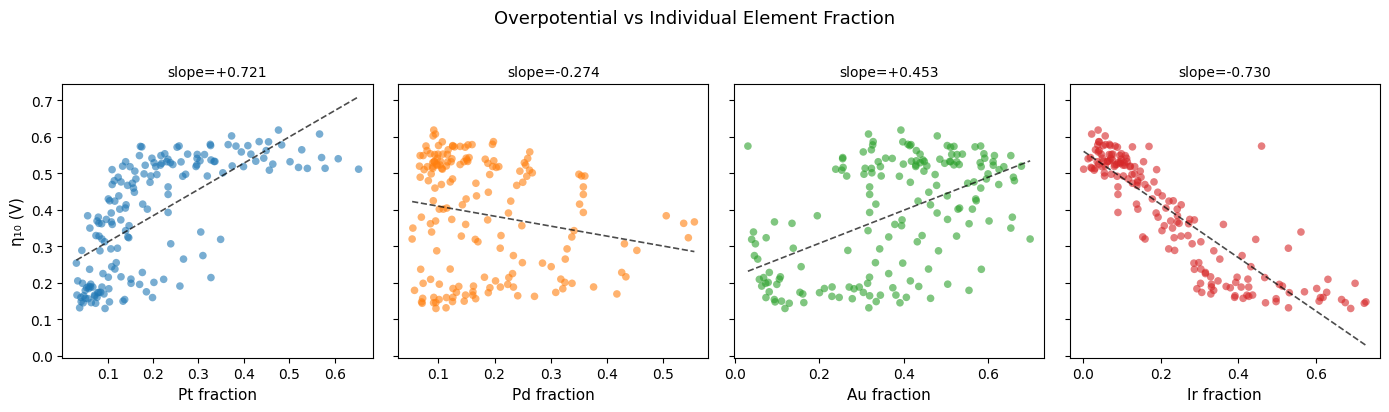

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, feat, c in zip(axes, FEATURES, colors):
    ax.scatter(
        df[feat], df[TARGET], alpha=0.6, s=30, color=c, edgecolors='none'
    )
    # Simple trend line
    m, b = np.polyfit(df[feat], df[TARGET], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', lw=1.2, ls='--', alpha=0.7)
    ax.set_xlabel(f'{feat} fraction', fontsize=11)
    ax.set_title(f'slope={m:+.3f}', fontsize=10)

axes[0].set_ylabel('η₁₀ (V)', fontsize=11)
fig.suptitle(
    'Overpotential vs Individual Element Fraction', fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('images/eta_vs_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Train / Test Split

In [4]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Train: 134  |  Test: 34


## 4. Model Suite

In [5]:
models = {
    'Ridge': Pipeline(
        [('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]
    ),
    'Random Forest': Pipeline(
        [
            ('scaler', StandardScaler()),
            (
                'model',
                RandomForestRegressor(n_estimators=200, random_state=SEED),
            ),
        ]
    ),
    'Gradient Boosting': Pipeline(
        [
            ('scaler', StandardScaler()),
            (
                'model',
                GradientBoostingRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=SEED,
                ),
            ),
        ]
    ),
    'SVR (RBF)': Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', SVR(kernel='rbf', C=10, epsilon=0.01)),
        ]
    ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

results = {}
for name, pipe in models.items():
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    cv_mse = cross_val_score(
        pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error'
    )
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_rmse': np.sqrt(-cv_mse.mean()),
        'test_r2': r2_score(y_test, y_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'test_mae': mean_absolute_error(y_test, y_pred),
        'pipeline': pipe,
        'y_pred': y_pred,
    }

res_df = pd.DataFrame(results).T[
    ['cv_r2_mean', 'cv_r2_std', 'cv_rmse', 'test_r2', 'test_rmse', 'test_mae']
]
res_df.columns = [
    'CV R² (mean)',
    'CV R² (std)',
    'CV RMSE',
    'Test R²',
    'Test RMSE',
    'Test MAE',
]
res_df.round(4)

,CV R² (mean),CV R² (std),CV RMSE,Test R²,Test RMSE,Test MAE
Ridge,0.806565,0.089088,0.065381,0.893162,0.053039,0.041498
Random Forest,0.863917,0.073907,0.054653,0.959901,0.032493,0.026217
Gradient Boosting,0.864777,0.062872,0.05462,0.943123,0.038699,0.030892
SVR (RBF),0.900464,0.033496,0.04693,0.967178,0.029398,0.022632


## 5. Parity Plots

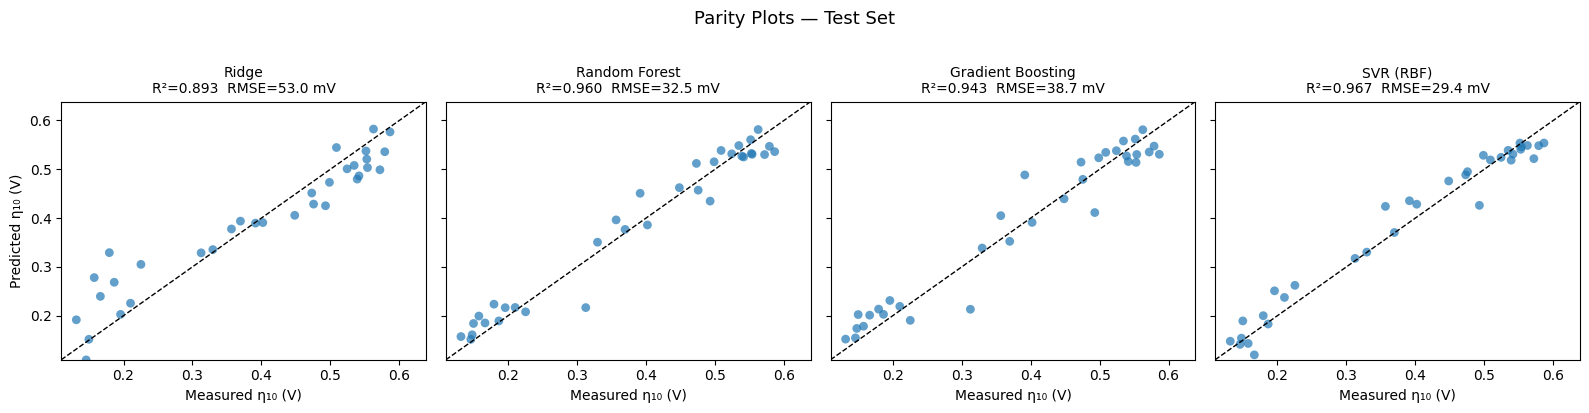

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, sharex=True)
lims = [y.min() - 0.02, y.max() + 0.02]

for ax, (name, r) in zip(axes, results.items()):
    ax.scatter(y_test, r['y_pred'], alpha=0.7, s=40, edgecolors='none')
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(
        f"{name}\nR²={r['test_r2']:.3f}  RMSE={r['test_rmse']*1000:.1f} mV",
        fontsize=10,
    )
    ax.set_xlabel('Measured η₁₀ (V)', fontsize=10)

axes[0].set_ylabel('Predicted η₁₀ (V)', fontsize=10)
fig.suptitle('Parity Plots — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('images/parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance (Best Model)

Permutation importance is model-agnostic and avoids the impurity-bias issue in tree-based importances.

Best model: SVR (RBF)  (Test R² = 0.9672)


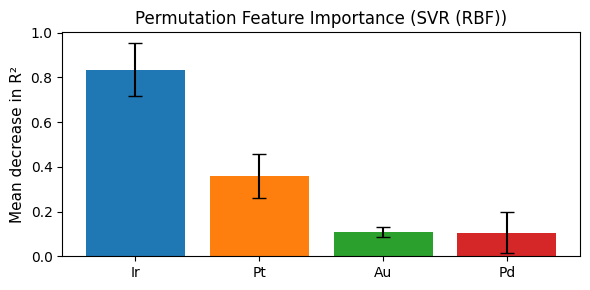

In [7]:
# Pick best model by test R²
best_name = max(results, key=lambda k: results[k]['test_r2'])
best_pipe = results[best_name]['pipeline']
print(
    f'Best model: {best_name}  (Test R² = {results[best_name]["test_r2"]:.4f})'
)

perm = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=30, random_state=SEED
)
sorted_idx = perm.importances_mean.argsort()[::-1]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(
    np.array(FEATURES)[sorted_idx],
    perm.importances_mean[sorted_idx],
    yerr=perm.importances_std[sorted_idx],
    capsize=5,
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
)
ax.set_ylabel('Mean decrease in R²', fontsize=11)
ax.set_title(f'Permutation Feature Importance ({best_name})', fontsize=12)
plt.tight_layout()
plt.savefig('images/feature_importance_eta.png', dpi=150, bbox_inches='tight')
plt.show()